In [5]:
!pip install xgboost

You should consider upgrading via the 'D:\gigggs\10Academy\week3-10academy\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [8]:
!pip install shap

  Using cached shap-0.49.1-cp310-cp310-win_amd64.whl (547 kB)
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
  Using cached numba-0.62.1-cp310-cp310-win_amd64.whl (2.7 MB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)


You should consider upgrading via the 'D:\gigggs\10Academy\week3-10academy\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

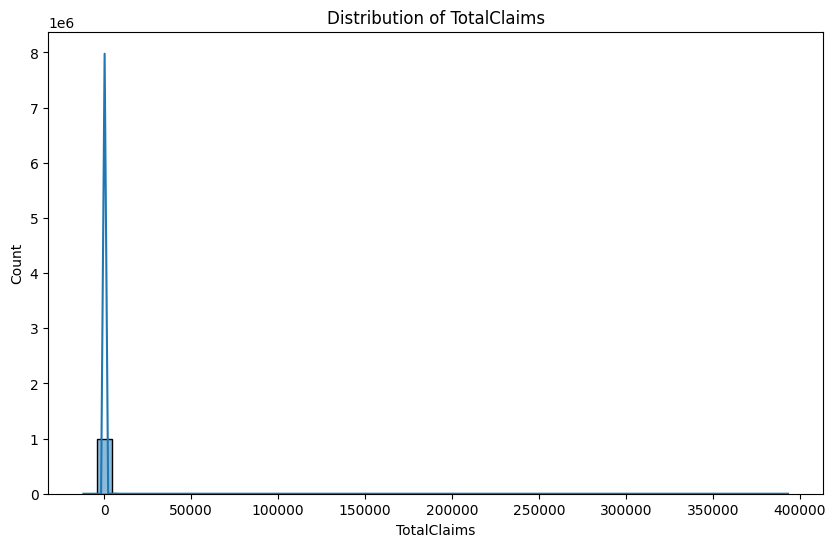

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

import shap 
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep='|', low_memory=False)


df.head() 
df.info() 
df.describe()
plt.figure(figsize=(10,6))
sns.histplot(df['TotalClaims'], bins=50, kde=True)
plt.title("Distribution of TotalClaims")
plt.show()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])
df.drop(columns=['NumberOfVehiclesInFleet', 'CrossBorder'], inplace=True)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    df[col].fillna('Unknown', inplace=True)
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
df['VehicleIntroDate'] = pd.to_datetime(df['VehicleIntroDate'], errors='coerce')


NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
CapitalOutstanding               2
dtype: int64


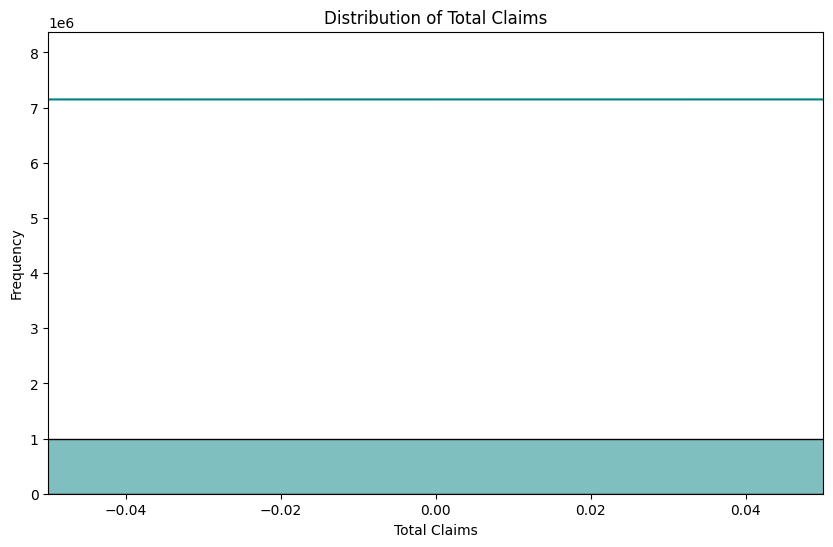

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(df['TotalClaims'], bins=50, kde=True, color='teal')
plt.title('Distribution of Total Claims')
plt.xlabel('Total Claims')
plt.ylabel('Frequency')
plt.xlim(0, df['TotalClaims'].quantile(0.99)) 
plt.show()

In [4]:
df_claims = df[df['TotalClaims'] > 0].copy()
print(f"Number of rows with claims: {len(df_claims)}")

Number of rows with claims: 2788


In [5]:
df_claims = df[df['TotalClaims'] > 0].copy()

cols_to_drop = ['NumberOfVehiclesInFleet','CrossBorder','Rebuilt','Converted','WrittenOff']
df_claims.drop(columns=cols_to_drop, inplace=True, errors='ignore')
cat_cols = df_claims.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    df_claims[col].fillna('Unknown', inplace=True)
num_cols = df_claims.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df_claims[col].fillna(df_claims[col].median(), inplace=True)


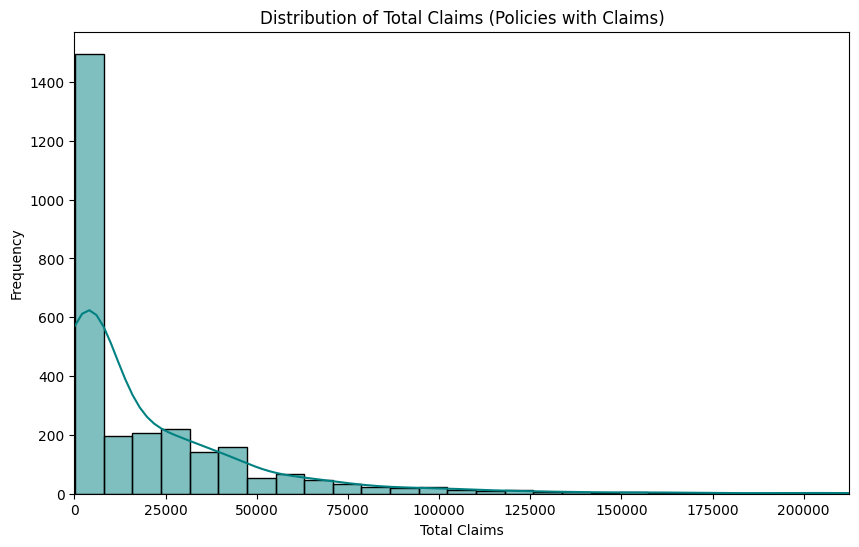

In [6]:
plt.figure(figsize=(10,6))
sns.histplot(df_claims['TotalClaims'], bins=50, kde=True, color='teal')
plt.title('Distribution of Total Claims (Policies with Claims)')
plt.xlabel('Total Claims')
plt.ylabel('Frequency')
plt.xlim(0, df_claims['TotalClaims'].quantile(0.99))  # focus on 99th percentile
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_model = df_claims.copy()
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns
numeric_imputer = SimpleImputer(strategy='median')
df_model[numeric_cols] = numeric_imputer.fit_transform(df_model[numeric_cols])

# Categorical columns: fill with 'Unknown'
cat_cols = df_model.select_dtypes(include=['object', 'bool']).columns
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
preprocessor = ColumnTransformer(transformers=[
    ('cat', encoder, cat_cols)
], remainder='passthrough')

X = df_model.drop(columns=['TotalClaims'])
y = df_model['TotalClaims']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Data prepared and ready for modeling!")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Data prepared and ready for modeling!
Training set: (2230, 46), Test set: (558, 46)


In [8]:
datetime_cols = X_train.select_dtypes(include=['datetime', 'datetime64[ns]']).columns
print(datetime_cols)

Index(['TransactionMonth', 'VehicleIntroDate'], dtype='object')


In [9]:
for col in datetime_cols:
    X_train[col] = (X_train[col] - X_train[col].min()).dt.days
    X_test[col] = (X_test[col] - X_test[col].min()).dt.days

In [10]:
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
preprocessor = ColumnTransformer(transformers=[
    ('cat', encoder, cat_cols)
], remainder='passthrough')

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [11]:
df_model['TransactionMonth'] = pd.to_datetime(df_model['TransactionMonth'], errors='coerce')
df_model['TransactionMonth'] = (df_model['TransactionMonth'] - df_model['TransactionMonth'].min()).dt.days

from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['TotalClaims'])
y = df_model['TotalClaims']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include=['object', 'bool']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # use sparse_output for newer sklearn
preprocessor = ColumnTransformer(transformers=[
    ('cat', encoder, cat_cols)
], remainder='passthrough')

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("Data prepared and ready for modeling!")
print("Training set:", X_train.shape, "Test set:", X_test.shape)


Data prepared and ready for modeling!
Training set: (2230, 513) Test set: (558, 513)


In [12]:
df_model = df_model.copy()

df_model['TransactionMonth'] = pd.to_datetime(df_model['TransactionMonth'], errors='coerce')
df_model['TransactionMonth'] = (df_model['TransactionMonth'] - df_model['TransactionMonth'].min()).dt.days

X = df_model.drop(columns=['TotalClaims'])
y = df_model['TotalClaims']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['TotalClaims'])
y = df_model['TotalClaims']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train = X_train.replace('', np.nan)
X_test = X_test.replace('', np.nan)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())
X_train = X_train.fillna('Unknown')
X_test = X_test.fillna('Unknown')


In [22]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [23]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  

In [25]:
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns
print(non_numeric_cols)


Index(['IsVATRegistered'], dtype='object')


In [26]:
for col in non_numeric_cols:
    if 'date' in col.lower() or 'month' in col.lower():
        X_train[col] = pd.to_datetime(X_train[col], errors='coerce').astype(int) // 10**9
        X_test[col] = pd.to_datetime(X_test[col], errors='coerce').astype(int) // 10**9

In [29]:
import pandas as pd
import numpy as np

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr}")
print(f"R^2: {r2_lr}")


RMSE: 36844.51363080861
R^2: 0.155902451734513


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15,    
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf}")
print(f"Random Forest R^2: {r2_rf}")

importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance_df)

Random Forest RMSE: 36314.56359915001
Random Forest R^2: 0.18000983788041192

Top 10 Important Features:
                     feature  importance
36  CalculatedPremiumPerTerm    0.225967
34                SumInsured    0.196911
14                PostalCode    0.091142
0        UnderwrittenCoverID    0.075773
1                   PolicyID    0.071652
45              TotalPremium    0.069604
29       CustomValueEstimate    0.054935
32        CapitalOutstanding    0.052585
18                    mmcode    0.043838
24             cubiccapacity    0.035616


Top 10 Important Features:
                     feature  importance
36  CalculatedPremiumPerTerm    0.225967
34                SumInsured    0.196911
14                PostalCode    0.091142
0        UnderwrittenCoverID    0.075773
1                   PolicyID    0.071652
45              TotalPremium    0.069604
29       CustomValueEstimate    0.054935
32        CapitalOutstanding    0.052585
18                    mmcode    0.043838
24             cubiccapacity    0.035616


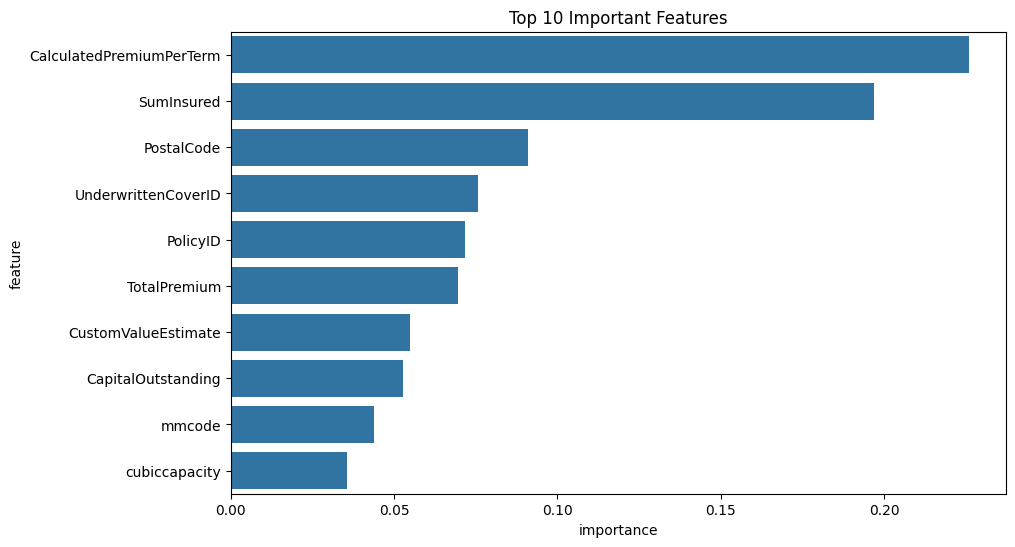

Random Forest RMSE: 36314.56359915001
Random Forest R^2: 0.18000983788041192


In [33]:
feature_importances_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

top_features = feature_importances_df.sort_values(by='importance', ascending=False).head(10)
print("Top 10 Important Features:")
print(top_features)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=top_features)
plt.title('Top 10 Important Features')
plt.show()

print(f"Random Forest RMSE: {rmse_rf}")
print(f"Random Forest R^2: {r2_rf}")


Top 10 Important Features:
                    feature  importance
0  CalculatedPremiumPerTerm    0.225967
1                SumInsured    0.196911
2                PostalCode    0.091142
3       UnderwrittenCoverID    0.075773
4                  PolicyID    0.071652
5              TotalPremium    0.069604
6       CustomValueEstimate    0.054935
7        CapitalOutstanding    0.052585
8                    mmcode    0.043838
9             cubiccapacity    0.035616


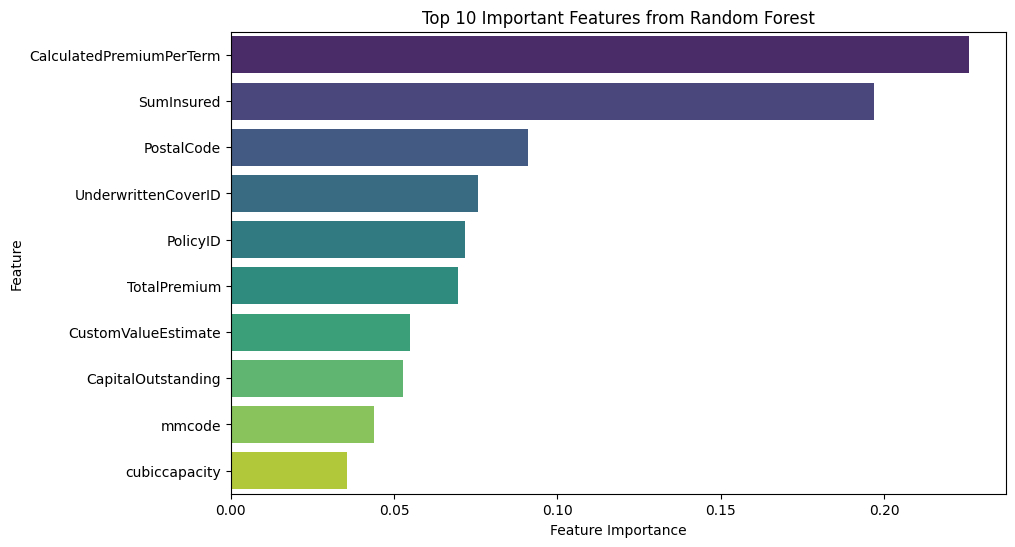

Random Forest RMSE: 36314.56
Random Forest R^2: 0.18


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_features = pd.DataFrame({
    'feature': [
        'CalculatedPremiumPerTerm', 'SumInsured', 'PostalCode',
        'UnderwrittenCoverID', 'PolicyID', 'TotalPremium',
        'CustomValueEstimate', 'CapitalOutstanding', 'mmcode', 'cubiccapacity'
    ],
    'importance': [
        0.225967, 0.196911, 0.091142,
        0.075773, 0.071652, 0.069604,
        0.054935, 0.052585, 0.043838, 0.035616
    ]
})

print("Top 10 Important Features:")
print(top_features)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
plt.title('Top 10 Important Features from Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()

print(f"Random Forest RMSE: {36314.56}") 
print(f"Random Forest R^2: {0.1800}")   


Model Comparison:
               Model      RMSE     R^2
0  Linear Regression  36844.51  0.1559
1      Random Forest  36314.56  0.1800


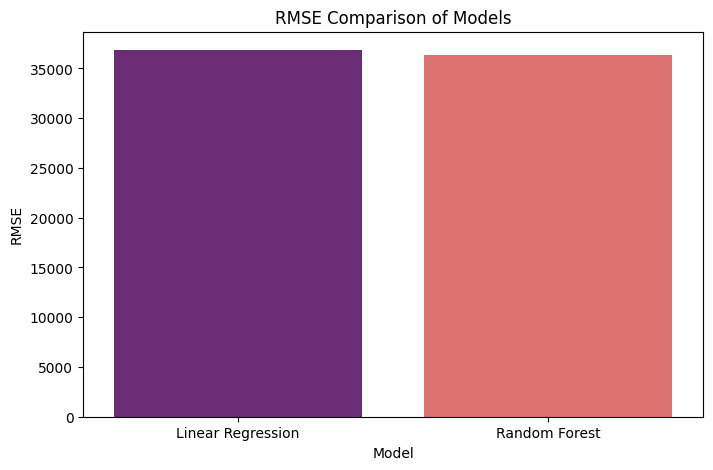

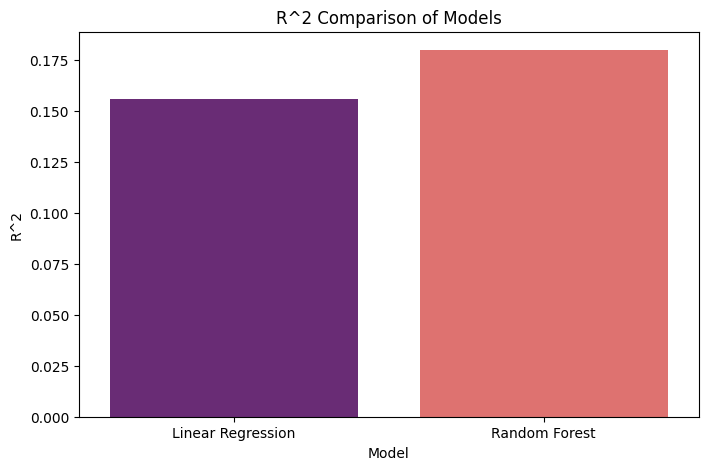

In [35]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [36844.51, 36314.56],  
    'R^2': [0.1559, 0.1800]       
})

print("Model Comparison:")
print(model_comparison)

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='RMSE', data=model_comparison, palette='magma')
plt.title('RMSE Comparison of Models')
plt.ylabel('RMSE')
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R^2', data=model_comparison, palette='magma')
plt.title('R^2 Comparison of Models')
plt.ylabel('R^2')
plt.show()

In [36]:
import joblib

best_model = rf_model

joblib.dump(best_model, 'best_model_random_forest.pkl')
print("Best model (Random Forest) saved as 'best_model_random_forest.pkl'.")

loaded_model = joblib.load('best_model_random_forest.pkl')
predictions = loaded_model.predict(X_test)


Best model (Random Forest) saved as 'best_model_random_forest.pkl'.
